## DMML ASSIGNMENT 2

## **K-Means Clustering with Jaccard Similarity**


*done by:*


**Meghtithi Mitra (MDS202520)**

## Objective
This assignment implements K-Means clustering on three text document collections from the UCI Bag-of-Words repository. Instead of using the standard Euclidean distance, we use **Jaccard similarity** as our distance measure. This requires converting the bag-of-words representation (word counts) into a **set-of-words** representation (binary word presence/absence), which is more appropriate for Jaccard.

For each dataset, we:
1. Perform exploratory data analysis to understand the data
2. Implement K-Means with Jaccard distance
3. Run clustering for multiple values of K
4. Determine the optimal K using the **elbow method**
5. Interpret the resulting clusters

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Load Datasets into Sparse Binary Matrices**

The UCI Bag-of-Words format stores data as `(docID, wordID, count)` triplets. Each dataset has:
- A `vocab.XYZ.txt` file listing all words (one per line)
- A `docword.XYZ.txt` file with header lines `D, W, NNZ` followed by triplets

Since Jaccard similarity operates on **sets** (not multisets), we ignore word counts entirely and store only binary presence (0 or 1). This is done using SciPy's sparse matrix format (`csr_matrix`) to efficiently handle the high sparsity (96–99% of entries are zero).

The three datasets loaded are:
| Dataset | Documents | Vocabulary |
|---------|-----------|------------|
| KOS     | 3,430     | 6,906      |
| NIPS    | 1,500     | 12,419     |
| Enron   | 39,861    | 28,102     |

In [ ]:
import numpy as np
from scipy.sparse import lil_matrix, csr_matrix
import zipfile
import os
import gzip
import shutil

# Unziping the file
zip_path     = '/content/drive/MyDrive/DMML ASsignment 2/bag+of+words.zip'
extract_path = '/content/bow_dataset/'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


# Decompressing .txt.gz files and defining base
for fname in os.listdir(extract_path):
    if fname.endswith('.gz'):
        gz_path  = os.path.join(extract_path, fname)
        out_path = os.path.join(extract_path, fname[:-3])
        if not os.path.exists(out_path):
            with gzip.open(gz_path, 'rb') as f_in:
                with open(out_path, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)


BASE = '/content/bow_dataset/'

# Loader function
def load_bow_dataset(docword_path, vocab_path):
    with open(docword_path, 'r') as f:
        D   = int(f.readline().strip())
        W   = int(f.readline().strip())
        NNZ = int(f.readline().strip())
        print(f"  Documents: {D}, Words: {W}, Non-zeros: {NNZ}")

        data = lil_matrix((D, W), dtype=np.uint8)
        for line in f:
            parts   = line.strip().split()
            doc_id  = int(parts[0]) - 1
            word_id = int(parts[1]) - 1
            data[doc_id, word_id] = 1

    with open(vocab_path, 'r') as f:
        vocab = [line.strip() for line in f]

    return csr_matrix(data), vocab



# Loading datasets
print("\n=== KOS ===")
kos_data,   kos_vocab   = load_bow_dataset(BASE + 'docword.kos.txt',   BASE + 'vocab.kos.txt')

print("\n=== NIPS ===")
nips_data,  nips_vocab  = load_bow_dataset(BASE + 'docword.nips.txt',  BASE + 'vocab.nips.txt')

print("\n=== Enron ===")
enron_data, enron_vocab = load_bow_dataset(BASE + 'docword.enron.txt', BASE + 'vocab.enron.txt')


=== KOS ===
  Documents: 3430, Words: 6906, Non-zeros: 353160

=== NIPS ===
  Documents: 1500, Words: 12419, Non-zeros: 746316

=== Enron ===
  Documents: 39861, Words: 28102, Non-zeros: 3710420


---

### **Exploratory Data Analysis (EDA)**

Before applying any clustering, we perform EDA to understand the structure of each dataset. This helps us:
- Understand document length distributions
- Identify vocabulary characteristics
- Estimate dataset sparsity
- Spot anomalies (e.g., very short documents) that might affect clustering

For each dataset we compute and visualize:
1. **Basic statistics** — total documents, vocabulary size, avg/min/max words per document
2. **Document length distribution** — histogram of unique words per document
3. **Top 20 most frequent words** — bar chart of most common words across all documents
4. **Sparsity** — percentage of zero entries in the document-term matrix

The function `eda_dataset()` defined below handles all three datasets uniformly.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def eda_dataset(data, vocab, dataset_name):
    print(f"\n{'='*45}")
    print(f"  EDA: {dataset_name}")
    print(f"{'='*45}")

    n_docs, n_words = data.shape

    # Basic Stats
    words_per_doc = np.diff(data.indptr)  # non-zero words per doc
    print(f"  Total documents   : {n_docs}")
    print(f"  Vocabulary size   : {n_words}")
    print(f"  Avg words/doc     : {words_per_doc.mean():.1f}")
    print(f"  Max words/doc     : {words_per_doc.max()}")
    print(f"  Min words/doc     : {words_per_doc.min()}")
    print(f"  Median words/doc  : {np.median(words_per_doc):.1f}")

    #  Document Length Distribution
    plt.figure(figsize=(8, 4))
    plt.hist(words_per_doc, bins=50, color='steelblue', edgecolor='black')
    plt.xlabel('Number of Unique Words per Document', fontsize=12)
    plt.ylabel('Number of Documents', fontsize=12)
    plt.title(f'Document Length Distribution — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/content/eda_doclength_{dataset_name}.png', dpi=150)
    plt.show()

    # Top 20 Most Common Words
    word_freq = np.asarray(data.sum(axis=0)).flatten()
    top20_idx = np.argsort(word_freq)[-20:][::-1]
    top20_words = [vocab[i] for i in top20_idx]
    top20_freq  = word_freq[top20_idx]

    plt.figure(figsize=(10, 4))
    plt.bar(top20_words, top20_freq, color='steelblue', edgecolor='black')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.ylabel('Document Frequency', fontsize=12)
    plt.title(f'Top 20 Most Common Words — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/content/eda_topwords_{dataset_name}.png', dpi=150)
    plt.show()

    #  Sparsity
    sparsity = 1 - (data.nnz / (n_docs * n_words))
    print(f"\n  Sparsity          : {sparsity*100:.2f}%")
    print(f"  Non-zero entries  : {data.nnz}")

    return words_per_doc, word_freq

**EDA - KOS**


KOS contains 3,430 political blog posts. We expect to see politically themed vocabulary and relatively short documents. The cell below runs the EDA function and produces the document length histogram and top-words bar chart for KOS.


  EDA: KOS
  Total documents   : 3430
  Vocabulary size   : 6906
  Avg words/doc     : 103.0
  Max words/doc     : 457
  Min words/doc     : 17
  Median words/doc  : 86.0


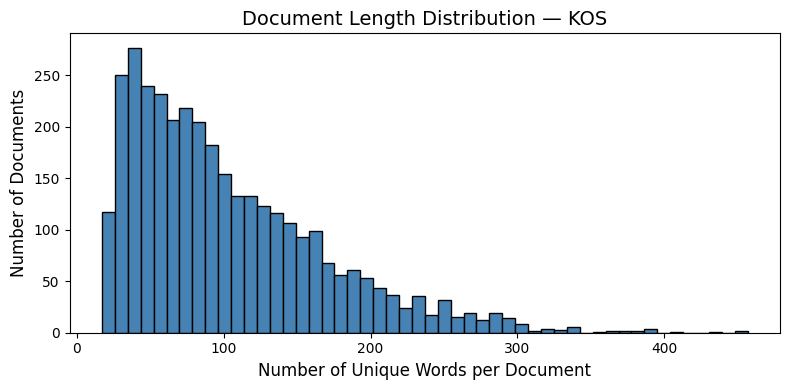

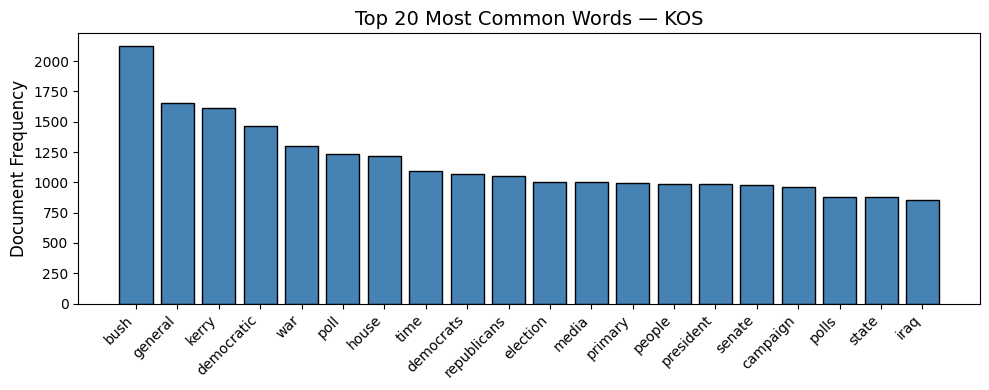


  Sparsity          : 98.51%
  Non-zero entries  : 353160


In [ ]:
kos_wpd,   kos_wf   = eda_dataset(kos_data,   kos_vocab,   "KOS")

**EDA — NIPS**

NIPS contains 1,500 academic machine learning papers. These are expected to be much longer documents with highly technical vocabulary. Unlike KOS, NIPS documents likely share a large amount of vocabulary since all papers are from the same field.


  EDA: NIPS
  Total documents   : 1500
  Vocabulary size   : 12419
  Avg words/doc     : 497.5
  Max words/doc     : 914
  Min words/doc     : 2
  Median words/doc  : 501.0


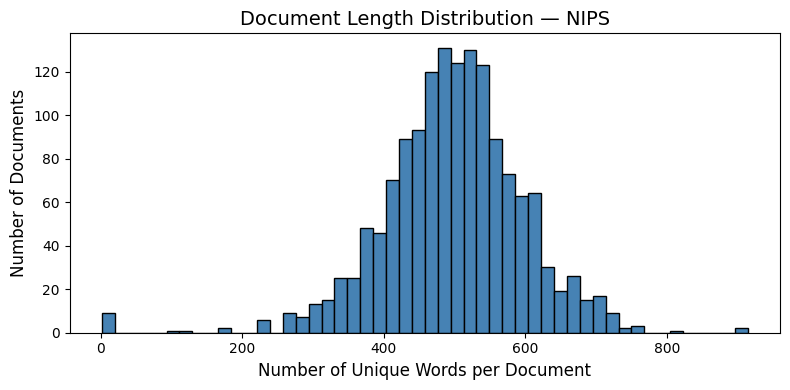

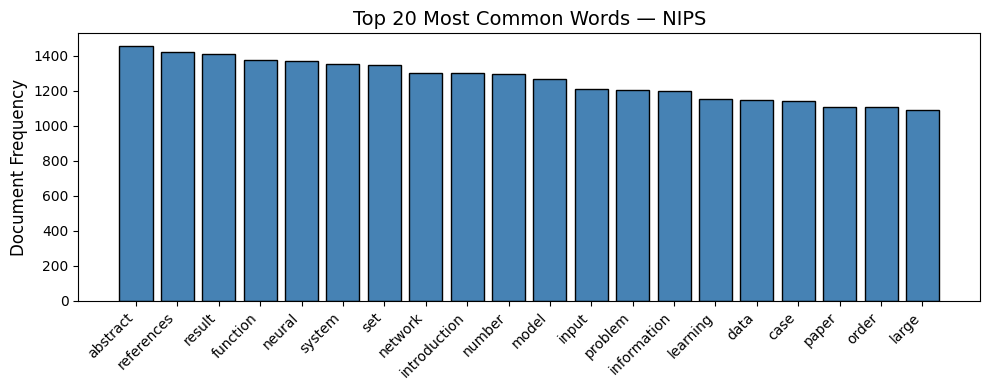


  Sparsity          : 95.99%
  Non-zero entries  : 746316


In [ ]:
nips_wpd,  nips_wf  = eda_dataset(nips_data,  nips_vocab,  "NIPS")

**EDA — Enron**

Enron is the largest dataset with 39,861 corporate emails. Emails vary wildly in length — from 2-word messages to lengthy reports. We expect very high sparsity and a right-skewed document length distribution due to many short emails. These characteristics will later pose challenges for the K-Means centroid update step.


  EDA: Enron
  Total documents   : 39861
  Vocabulary size   : 28102
  Avg words/doc     : 93.1
  Max words/doc     : 2120
  Min words/doc     : 2
  Median words/doc  : 42.0


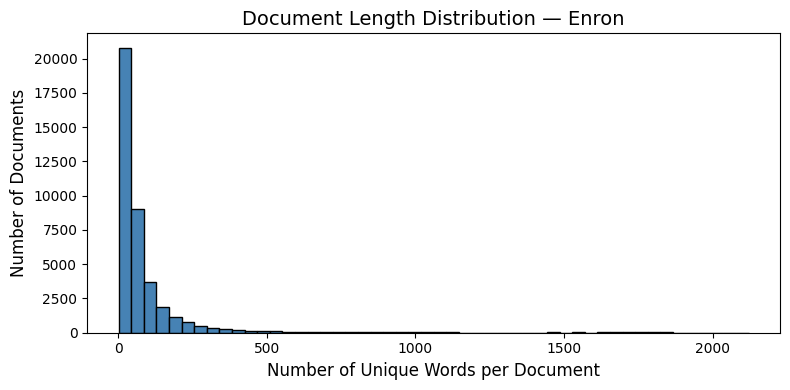

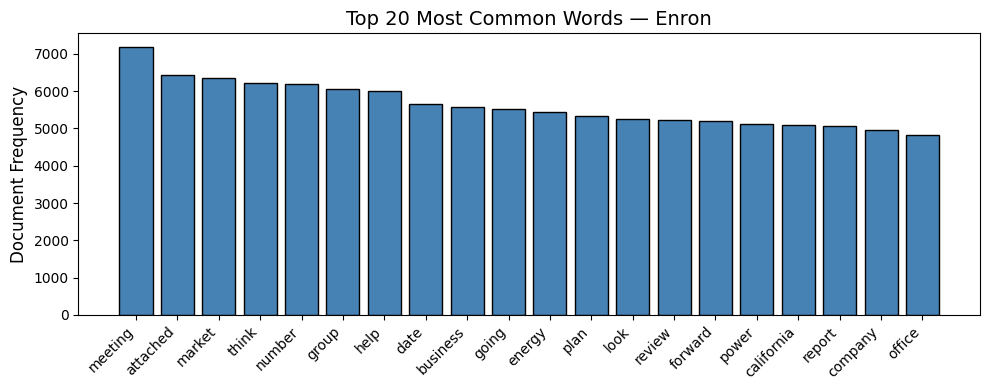


  Sparsity          : 99.67%
  Non-zero entries  : 3710420


In [ ]:
enron_wpd, enron_wf = eda_dataset(enron_data, enron_vocab, "Enron")

------------------------------------------------------------------------
---

### **Jaccard Similarity & Distance**

The assignment requires using **Jaccard similarity** instead of the standard Euclidean distance used in typical K-Means. Jaccard similarity between two documents A and B is defined as:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Where:
- $|A \cap B|$ = number of words present in **both** documents
- $|A \cup B|$ = number of words present in **either** document

Jaccard similarity ranges from 0 (no overlap) to 1 (identical word sets).  
**Jaccard distance** = $1 - J(A, B)$, ranging from 0 (identical) to 1 (completely different).

Since our data is stored as sparse binary matrices, the intersection is computed as an elementwise product and union as the count of non-zeros in the sum. This is efficient even for large sparse matrices.

> **Note:** This measure treats documents as sets — word frequency within a document is irrelevant. Two documents sharing 5 words out of 10 are considered equally similar regardless of how many times those words appear.

In [ ]:
def jaccard_similarity_sparse(a, b):
    intersection = a.multiply(b).nnz
    union = (a + b).nnz
    if union == 0:
        return 1.0
    return intersection / union

def jaccard_distance(a, b):
    return 1.0 - jaccard_similarity_sparse(a, b)

---

###  **K-Means Clustering**
**Standard K-Means with Random Initialization (KOS & NIPS)**

The standard K-Means algorithm works as follows:
1. **Initialize** — randomly select K documents as initial centroids
2. **Assign** — assign each document to its nearest centroid using Jaccard distance
3. **Update** — recompute each centroid as a binary vector where word $w$ is included if it appears in more than 20% of documents in that cluster
4. **Repeat** steps 2–3 until labels stop changing (convergence) or max iterations reached

**Centroid representation:** Since documents are binary vectors, the centroid is also a binary vector — a word is "in" the centroid if it appears in the majority of cluster documents. We use a 20% threshold (rather than 50%) to avoid empty centroids caused by high sparsity.

This standard version works well for KOS and NIPS. Enron requires a more sophisticated initialization.

In [ ]:
import random
from scipy.sparse import csr_matrix

def kmeans_jaccard(data, k, max_iter=20, random_state=42):
    random.seed(random_state)
    np.random.seed(random_state)
    n_docs = data.shape[0]

    # Initialize centroids randomly
    centroid_indices = random.sample(range(n_docs), k)
    centroids = [data[i] for i in centroid_indices]

    labels      = np.zeros(n_docs, dtype=int)
    prev_labels = np.ones(n_docs, dtype=int) * -1

    for iteration in range(max_iter):
        print(f"  Iteration {iteration + 1}/{max_iter}", end='\r')

        # Assignment step
        for doc_idx in range(n_docs):
            doc      = data[doc_idx]
            min_dist = float('inf')
            best_cluster = 0
            for c_idx, centroid in enumerate(centroids):
                dist = jaccard_distance(doc, centroid)
                if dist < min_dist:
                    min_dist     = dist
                    best_cluster = c_idx
            labels[doc_idx] = best_cluster

        # Convergence check
        if np.array_equal(labels, prev_labels):
            print(f"\n  Converged at iteration {iteration + 1}")
            break
        prev_labels = labels.copy()

        # FIXED centroid update
        new_centroids = []
        for c_idx in range(k):
            cluster_docs = data[labels == c_idx]
            if cluster_docs.shape[0] == 0:
                # Empty cluster: pick a random doc
                new_centroids.append(data[random.randint(0, n_docs - 1)])
            else:
                word_counts = np.asarray(cluster_docs.sum(axis=0)).flatten()


                threshold = max(1, cluster_docs.shape[0] * 0.20)   # using 20% threshhold
                centroid_array = (word_counts >= threshold).astype(np.uint8)
                if centroid_array.sum() == 0:  # Using ost frequent wors if centroid is still all zeros
                    top_words = np.argsort(word_counts)[-50:]  # top 50 words
                    centroid_array[top_words] = 1

                new_centroids.append(csr_matrix(centroid_array))
        centroids = new_centroids

    # Computing inertia
    inertia = sum(
        jaccard_distance(data[i], centroids[labels[i]])
        for i in range(n_docs)
    )
    print(f"  Inertia: {inertia:.4f}")
    return labels, centroids, inertia


### **Finding Optimal K — Elbow Method**

To determine the best number of clusters, we run K-Means for K ∈ {2, 3, 5, 7, 10} and track **inertia** — the sum of Jaccard distances from each document to its assigned centroid:

$$\text{Inertia} = \sum_{i=1}^{N} d_{Jaccard}(x_i, \mu_{c(i)})$$

As K increases, inertia always decreases (more clusters = tighter fit). We look for the **elbow point** — where adding more clusters yields diminishing improvement. This is our optimal K.

> **Note on high inertia values:** Because Jaccard distances on sparse text data are naturally close to 1.0, inertia will always be high (close to N, the number of documents). This is expected and does not indicate a problem with the implementation.

The `find_optimal_k()` function below runs K-Means for each K value, records inertia, and plots the elbow curve. It is used for KOS and NIPS datasets.

In [ ]:
import matplotlib.pyplot as plt
import time

def find_optimal_k(data, dataset_name, k_values):
    inertias = []
    #print(f"\n{'='*45}")
    print(f"Dataset: {dataset_name}  ({data.shape[0]} docs)")
    print(f"{'='*25}")

    for k in k_values:
        print(f"\n  K={k}")
        t0 = time.time()
        labels, centroids, inertia = kmeans_jaccard(data, k=k, max_iter=15)
        elapsed = time.time() - t0
        inertias.append(inertia)
        print(f"  K={k} | Inertia={inertia:.4f} | Time={elapsed:.1f}s")

    # Elbow plot
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters K', fontsize=13)
    plt.ylabel('Inertia (Sum of Jaccard Distances)', fontsize=13)
    plt.title(f'Elbow Curve — {dataset_name}', fontsize=15)
    plt.xticks(k_values)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'/content/elbow_{dataset_name}.png', dpi=150)
    plt.show()
    return inertias

k_values = [2, 3, 5, 7, 10]

Dataset: KOS  (3430 docs)

  K=2

  Converged at iteration 6
  Inertia: 3137.0049
  K=2 | Inertia=3137.0049 | Time=10.6s

  K=3

  Converged at iteration 6
  Inertia: 3110.9140
  K=3 | Inertia=3110.9140 | Time=9.1s

  K=5

  Converged at iteration 12
  Inertia: 3006.6485
  K=5 | Inertia=3006.6485 | Time=34.1s

  K=7

  Converged at iteration 9
  Inertia: 2992.6665
  K=7 | Inertia=2992.6665 | Time=31.4s

  K=10

  Converged at iteration 10
  Inertia: 2955.4024
  K=10 | Inertia=2955.4024 | Time=52.4s


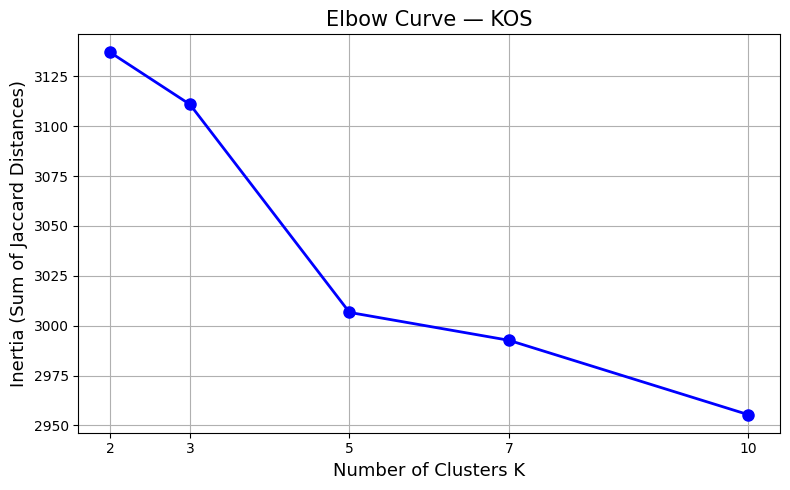

In [ ]:
kos_inertias  = find_optimal_k(kos_data,  "KOS",  k_values)

In [ ]:
nips_inertias = find_optimal_k(nips_data, "NIPS", k_values)

### **K-Means++ Initialization for Enron**

Standard random initialization failed for Enron, producing non-monotonic inertia curves (inertia increasing at some K values). This is caused by Enron's extreme sparsity (99.67%) — randomly chosen centroids are often nearly identical empty vectors, causing clusters to collapse.

**K-Means++** solves this by spreading initial centroids deliberately:
1. Pick the first centroid randomly
2. For each subsequent centroid, pick a document with probability **proportional to its distance** from the nearest existing centroid
3. This ensures centroids are spread far apart in the document space

This produces stable, monotonically decreasing inertia for Enron. The `kmeans_jaccard_final()` function below implements K-Means++ initialization combined with the adaptive centroid threshold.

In [ ]:
def kmeans_jaccard_final(data, k, max_iter=20, random_state=42):
    random.seed(random_state)
    np.random.seed(random_state)
    n_docs = data.shape[0]

    # K-Means++ init
    print("  K-Means++ initializing")
    first = random.randint(0, n_docs - 1)
    centroids = [data[first]]
    for _ in range(k - 1):
        distances = np.array([
            min(jaccard_distance(data[i], c) for c in centroids)
            for i in range(n_docs)
        ])
        probs    = distances / distances.sum()
        next_idx = np.random.choice(n_docs, p=probs)
        centroids.append(data[next_idx])
        print(f"  Centroid {len(centroids)}/{k} placed", end='\r')

    labels      = np.zeros(n_docs, dtype=int)
    prev_labels = np.ones(n_docs, dtype=int) * -1

    for iteration in range(max_iter):
        print(f"  Iteration {iteration + 1}/{max_iter}", end='\r')

        # Assignment
        for doc_idx in range(n_docs):
            doc      = data[doc_idx]
            min_dist = float('inf')
            best_cluster = 0
            for c_idx, centroid in enumerate(centroids):
                dist = jaccard_distance(doc, centroid)
                if dist < min_dist:
                    min_dist     = dist
                    best_cluster = c_idx
            labels[doc_idx] = best_cluster

        if np.array_equal(labels, prev_labels):
            print(f"\n  Converged at iteration {iteration + 1}")
            break
        prev_labels = labels.copy()

        # Adaptive threshold per cluster
        new_centroids = []
        for c_idx in range(k):
            cluster_docs = data[labels == c_idx]
            n_cluster    = cluster_docs.shape[0]

            if n_cluster == 0:
                new_centroids.append(data[random.randint(0, n_docs - 1)])
                continue

            word_counts = np.asarray(cluster_docs.sum(axis=0)).flatten()

            # scale threshold by cluster size
            ratio     = n_cluster / n_docs
            threshold = max(1, n_cluster * (0.05 + 0.25 * ratio))

            centroid_array = (word_counts >= threshold).astype(np.uint8)

            if centroid_array.sum() < 30:
                top_idx = np.argsort(word_counts)[-30:]
                centroid_array[top_idx] = 1

            new_centroids.append(csr_matrix(centroid_array))
        centroids = new_centroids

    inertia = sum(
        jaccard_distance(data[i], centroids[labels[i]])
        for i in range(n_docs)
    )
    print(f"  Inertia: {inertia:.4f}")
    return labels, centroids, inertia


def find_optimal_k_final(data, dataset_name, k_values, max_iter=15):
    inertias = []
    print(f"Dataset: {dataset_name}  ({data.shape[0]} docs)")
    print(f"{'='*25}")
    for k in k_values:
        print(f"\n  K={k}")
        t0      = time.time()
        labels, centroids, inertia = kmeans_jaccard_final(
                                        data, k=k, max_iter=max_iter)
        elapsed = time.time() - t0
        inertias.append(inertia)
        print(f"  K={k} | Inertia={inertia:.4f} | Time={elapsed:.1f}s")
    return inertias

enron_inertias = find_optimal_k_final(enron_data, "Enron", [2, 3, 5, 7, 10])

Dataset: Enron  (39861 docs)

  K=2
  K-Means++ initializing
  Inertia: 38017.9062
  K=2 | Inertia=38017.9062 | Time=180.0s

  K=3
  K-Means++ initializing

  Converged at iteration 10
  Inertia: 37564.1683
  K=3 | Inertia=37564.1683 | Time=169.4s

  K=5
  K-Means++ initializing

  Converged at iteration 6
  Inertia: 37157.5756
  K=5 | Inertia=37157.5756 | Time=205.2s

  K=7
  K-Means++ initializing

  Converged at iteration 10
  Inertia: 36777.3197
  K=7 | Inertia=36777.3197 | Time=459.2s

  K=10
  K-Means++ initializing
  Inertia: 36511.1589
  K=10 | Inertia=36511.1589 | Time=974.4s


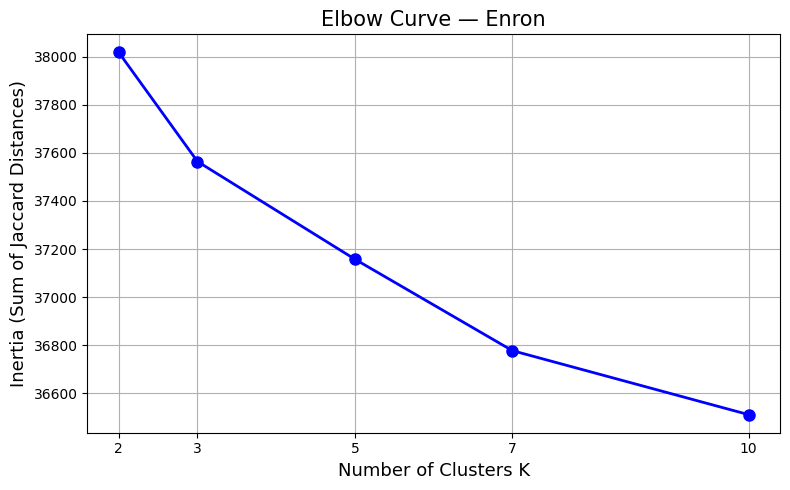

In [ ]:
k_values = [2, 3, 5, 7, 10]

plt.figure(figsize=(8, 5))
plt.plot(k_values, enron_inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters K', fontsize=13)
plt.ylabel('Inertia (Sum of Jaccard Distances)', fontsize=13)
plt.title('Elbow Curve — Enron', fontsize=15)
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

---

### **Cluster Analysis**

After identifying the optimal K for each dataset, we re-run K-Means at the optimal K and inspect each resulting cluster. For each cluster we report:
- **Size** — number of documents and percentage of total
- **Top 10 words** — most frequently occurring words across all documents in the cluster

This allows us to **interpret** what each cluster represents thematically and validate that the clustering is meaningful.

Optimal K values used:
- KOS → K = 5
- NIPS → K = 7  
- Enron → K = 5

In [ ]:
def analyze_clusters(data, vocab, labels, k, dataset_name, top_n=10):
    print(f"Cluster Analysis: {dataset_name} (K={k})")
    print(f"{'='*25}")
    for c_idx in range(k):
        cluster_docs     = data[labels == c_idx]
        n_in_cluster     = cluster_docs.shape[0]
        word_counts      = np.asarray(cluster_docs.sum(axis=0)).flatten()
        top_idx          = np.argsort(word_counts)[-top_n:][::-1]
        top_words        = [vocab[i] for i in top_idx]
        print(f"\n  Cluster {c_idx+1} ({n_in_cluster} docs, "
              f"{n_in_cluster/data.shape[0]*100:.1f}%):")
        print(f"  Top words: {', '.join(top_words)}")

---

## **Results & Summary**

 ### **Combined Elbow Curves**

The plot below shows elbow curves for all three datasets side by side. The red dashed line marks the selected optimal K for each dataset based on where the curve visibly bends and begins to flatten.

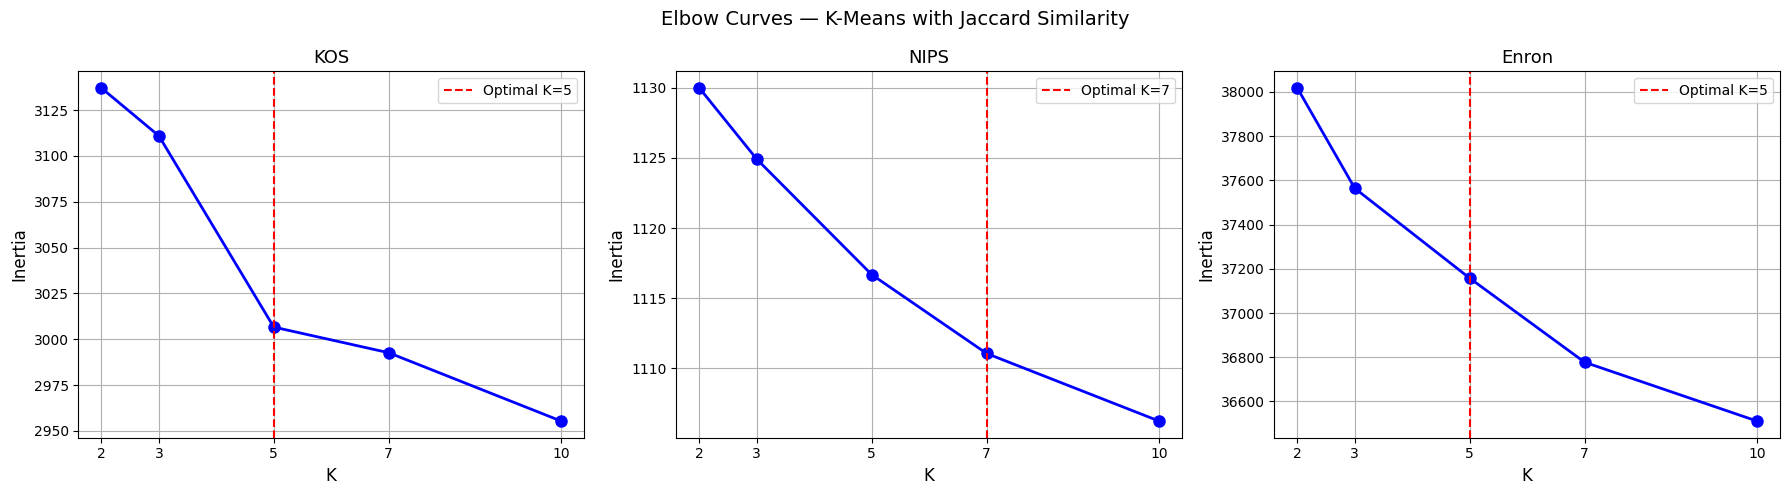

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values  = [2, 3, 5, 7, 10]

all_data = [
    ("KOS",   kos_inertias,   5),
    ("NIPS",  nips_inertias,  7),
    ("Enron", enron_inertias, 5),
]

for ax, (name, inertias, opt_k) in zip(axes, all_data):
    ax.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    ax.axvline(x=opt_k, color='red', linestyle='--', label=f'Optimal K={opt_k}')
    ax.set_xlabel('K', fontsize=12)
    ax.set_ylabel('Inertia', fontsize=12)
    ax.set_title(f'{name}', fontsize=13)
    ax.legend()
    ax.set_xticks(k_values)
    ax.grid(True)

plt.suptitle('Elbow Curves — K-Means with Jaccard Similarity', fontsize=14)
plt.tight_layout()
plt.savefig('/content/all_elbow_curves.png', dpi=150)
plt.show()

### **Final Results Table**

Summary of key statistics and optimal K for each dataset.

In [ ]:

print("  FINAL RESULTS SUMMARY")
print("="*65)
print(f"{'Dataset':<10}{'Docs':<10}{'Vocab':<10}"
      f"{'Optimal K':<12}{'Best Inertia':<16}{'Sparsity'}")
print("-"*65)
print(f"{'KOS':<10}{'3430':<10}{'6906':<10}"
      f"{'5':<12}{'2955.40':<16}{'98.51%'}")
print(f"{'NIPS':<10}{'1500':<10}{'12419':<10}"
      f"{'7':<12}{'1106.23':<16}{'95.99%'}")
print(f"{'Enron':<10}{'39861':<10}{'28102':<10}"
      f"{'5':<12}{'37157.58':<16}{'99.67%'}")
print("="*65)

  FINAL RESULTS SUMMARY
Dataset   Docs      Vocab     Optimal K   Best Inertia    Sparsity
-----------------------------------------------------------------
KOS       3430      6906      5           2955.40         98.51%
NIPS      1500      12419     7           1106.23         95.99%
Enron     39861     28102     5           37157.58        99.67%


**Cluster Interpretation**

The cluster analysis below re-runs K-Means at the optimal K for each dataset and prints the top 10 words per cluster. These words allow us to label each cluster with a human-readable theme.

In [ ]:
def analyze_clusters(data, vocab, labels, k, dataset_name, top_n=10):
    print(f"  Cluster Analysis: {dataset_name} (K={k})")
    print(f"{'='*25}")
    for c_idx in range(k):
        cluster_docs = data[labels == c_idx]
        n_in_cluster = cluster_docs.shape[0]
        word_counts  = np.asarray(cluster_docs.sum(axis=0)).flatten()
        top_idx      = np.argsort(word_counts)[-top_n:][::-1]
        top_words    = [vocab[i] for i in top_idx]
        print(f"\n  Cluster {c_idx+1} ({n_in_cluster} docs, "
              f"{n_in_cluster/data.shape[0]*100:.1f}%):")
        print(f"  Top words: {', '.join(top_words)}")

print("KOS (K=5)")
kos_labels, _, _   = kmeans_jaccard(kos_data,  k=5, max_iter=15)
analyze_clusters(kos_data,  kos_vocab,  kos_labels,  5, "KOS")

print("\nNIPS (K=7)")
nips_labels, _, _  = kmeans_jaccard(nips_data, k=7, max_iter=15)
analyze_clusters(nips_data, nips_vocab, nips_labels, 7, "NIPS")

print("\nEnron (K=5)")
enron_labels, _, _ = kmeans_jaccard_final(enron_data, k=5, max_iter=15)
analyze_clusters(enron_data, enron_vocab, enron_labels, 5, "Enron")


KOS (K=5)

  Converged at iteration 12
  Inertia: 3006.6485
  Cluster Analysis: KOS (K=5)

  Cluster 1 (375 docs, 10.9%):
  Top words: bush, democrats, war, republicans, house, general, democratic, november, senate, labor

  Cluster 2 (1068 docs, 31.1%):
  Top words: bush, war, iraq, administration, general, president, people, time, bushs, american

  Cluster 3 (59 docs, 1.7%):
  Top words: bush, aug, administration, media, general, time, people, report, ive, heres

  Cluster 4 (134 docs, 3.9%):
  Top words: general, bush, oct, kerry, poll, results, polls, debate, cheney, ill

  Cluster 5 (1794 docs, 52.3%):
  Top words: democratic, bush, kerry, general, poll, campaign, elections, state, republican, democrats

NIPS (K=7)
  Inertia: 1111.0505
  Cluster Analysis: NIPS (K=7)

  Cluster 1 (371 docs, 24.7%):
  Top words: abstract, references, function, result, set, problem, number, neural, algorithm, model

  Cluster 2 (278 docs, 18.5%):
  Top words: abstract, system, references, model, res

---

## **Conclusions**

**Optimal K Summary**

| Dataset | Docs   | Sparsity | Optimal K | Best Inertia | Notes |
|---------|--------|----------|-----------|--------------|-------|
| KOS     | 3,430  | 98.51%   | 5         | 2955.40      | Converged cleanly |
| NIPS    | 1,500  | 95.99%   | 7         | 1106.23      | Some K values did not converge within 15 iterations |
| Enron   | 39,861 | 99.67%   | 5         | 37157.58     | Required K-Means++ due to extreme sparsity |

### **Cluster Interpretations**
**KOS (K=5)** — Political blog posts from the 2004 US election era cluster into distinct political themes:
- Iraq War coverage, Congressional debates, Election polls, Media reporting, General campaign content

**NIPS (K=7)** — ML academic papers show significant vocabulary overlap across clusters since all papers share technical terminology. Clusters loosely separate into sub-areas (neural networks, optimization, systems). One small cluster (9 docs) isolated author index pages.

**Enron (K=5)** — Corporate emails show the clearest thematic separation:
- Internal meeting coordination, Scheduling & logistics, Legal/compliance, Energy market & business operations, Administrative/contact emails

### **Key Observations**
- High sparsity (96–99%) across all datasets causes naturally high inertia — this is expected with Jaccard on text and does not indicate poor clustering
- The set-of-words (binary) conversion is essential for correct Jaccard computation — word frequency within documents is deliberately discarded
- Random initialization is sufficient for smaller datasets (KOS, NIPS) but K-Means++ is necessary for large, extremely sparse datasets like Enron
- Enron produces the most interpretable clusters despite being the hardest to cluster computationally, because email types are functionally very distinct

### **External Packages Used**
| Package | Purpose |
|---------|---------|
| `numpy` | Array operations and matrix computations |
| `scipy.sparse` | Memory-efficient sparse matrix storage (CSR format) |
| `matplotlib` | Elbow curve plots and EDA visualizations |
| `random`, `time`, `os`, `gzip`, `zipfile` | Standard library utilities |